<a href="https://colab.research.google.com/github/khalid-bin-Nasir-0/ML_arrena/blob/main/ML_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# hackathon

In [474]:
# import dependencies

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [475]:
# load training data frame
dt_df = pd.read_csv('/content/drive/MyDrive/ML Challenge Dataset/TRAIN.csv')

In [476]:
dt_df.head()

,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class
0,0.185570,0.004568,0.005362,0.003335,0.005415,0.004895,0.012764,0.120138,0.140450,3.361753,...,0.041526,-0.230857,0.003310,0.042250,0.005975,0.002104,0.013878,0.001518,0.011347,0
1,0.369536,0.003983,0.003386,0.004902,0.007570,0.012136,0.118050,0.323925,0.132093,2.766117,...,-0.141285,-6.222857,0.834177,0.227968,0.018463,-0.020487,0.001246,0.007489,0.008724,1
2,0.602510,0.008442,0.012961,0.012870,0.046885,0.115401,0.065688,0.306677,0.498805,4.521201,...,0.011334,10.335251,-0.276614,-0.198900,-0.012756,0.014286,-0.001866,0.002687,0.013452,1
3,0.347957,0.064721,0.013611,0.011541,0.006492,0.008690,0.013192,0.164553,0.298665,3.170847,...,0.190479,2.864912,-1.921939,0.891690,1.108098,0.635431,0.081368,-0.000225,0.009166,0
4,0.233653,0.012217,0.010088,0.022095,0.026040,0.015062,0.016063,0.084648,0.213367,8.150943,...,0.203164,0.001812,-0.092731,0.005280,-0.213985,0.032195,0.002081,0.028930,-0.025912,1


In [477]:
dt_df.tail()

,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class
43771,1.231065,0.008631,0.010488,0.030072,0.224300,0.384893,0.452580,0.878004,0.583311,4.336341,...,0.076438,-10.673305,0.874835,0.035450,0.001390,-0.003333,0.002385,0.001182,-0.010616,1
43772,1.576213,0.019906,0.015115,0.034719,0.347274,0.913438,0.240656,0.469324,1.118124,3.395661,...,-0.033483,-19.302853,5.744947,0.373802,0.006406,-0.008244,-0.081317,-0.007015,-0.001864,1
43773,0.523951,0.006851,0.012379,0.008150,0.012631,0.012130,0.033749,0.150855,0.500064,3.677857,...,0.051253,0.825418,0.006428,-0.012533,-0.034026,0.000177,0.005071,0.005763,0.005489,0
43774,0.313915,0.003392,0.004212,0.004475,0.004765,0.005470,0.017687,0.034267,0.311377,2.097170,...,-0.012220,-0.630316,-0.006486,-0.042303,0.037734,0.039146,-0.008112,-0.001419,0.000728,1
43775,0.206646,0.014795,0.012043,0.020157,0.044076,0.029703,0.021559,0.108707,0.163788,3.503771,...,-0.034282,0.027310,-0.197855,-0.003869,-0.039651,-0.009938,0.006735,0.000255,-0.020324,1


In [478]:
# finding null value
dt_df.isnull().sum()

,0
F01,0
F02,0
F03,0
F04,0
F05,0
F06,0
F07,0
F08,0
F09,0
F10,0


In [479]:
dt_df['Class'].value_counts()

,count
Class,
0,26465
1,17311


In [480]:
# it gives us the duplicate value

dt_df.value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28,F29,F30,F31,F32,F33,F34,F35,F36,F37,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class,
0.109903,0.003664,0.004686,0.006191,0.012606,0.043063,0.017137,0.085000,0.049742,3.441926,2.023761,2.918763,3.553009,3.700598,3.581887,3.979420,3.598089,3.653228,0.389621,0.000002,0.358444,0.184589,0.174493,0.101362,0.109910,0.178753,0.045990,0.078894,0.036977,2.837961,2.831352,2.711700,3.167829,3.346859,2.897369,3.067966,2.967055,2.734791,-0.014636,-0.137748,0.098521,-0.008560,-0.009561,-0.002583,0.008568,-0.000004,0.037813,0,2
0.109917,0.005093,0.004238,0.007203,0.013626,0.025217,0.016437,0.085504,0.059861,3.738161,2.881645,3.149232,3.594013,3.321779,3.785098,4.244494,3.812439,3.809838,0.442783,0.000007,0.394875,0.267530,0.196255,0.095306,0.125219,0.107588,0.034727,0.079571,0.042575,2.852368,3.054612,3.144500,3.388077,2.812142,2.915668,3.249291,3.017183,3.005687,0.021517,-0.005339,-0.023357,0.009735,-0.009936,0.005765,0.000999,-0.000970,0.067199,0,2
0.259404,0.008833,0.018102,0.023415,0.069234,0.039852,0.017301,0.051079,0.238838,3.551377,1.995073,2.132716,3.045590,2.700802,3.410214,3.908834,3.585317,3.200017,0.935512,-0.000023,1.174901,0.392835,0.789049,0.289333,0.687650,0.174825,0.046984,0.043082,0.109181,2.695307,2.771203,1.987315,2.829536,2.163092,2.838939,3.031446,2.880171,2.623487,0.001254,-0.114114,0.014184,-0.000264,-0.000083,-0.004438,-0.007134,0.000698,0.000393,0,2
0.109944,0.004679,0.005032,0.006885,0.014809,0.031291,0.011727,0.091279,0.048253,3.224723,1.952069,3.088654,3.148448,3.328137,3.708582,4.286591,3.358744,4.087219,0.371494,-0.000022,0.382968,0.226550,0.199524,0.106024,0.129808,0.134136,0.030234,0.083745,0.037015,2.664269,16.881634,2.868770,3.167895,2.742334,2.888320,3.154736,2.776771,2.950669,-0.059083,-1.110079,0.145212,0.015837,-0.020339,-0.003049,0.007004,-0.000070,0.059586,0,2
0.157990,0.003309,0.003062,0.010676,0.020793,0.025852,0.022864,0.144554,0.048024,3.071302,2.221690,3.000737,3.482144,3.193670,3.572363,3.678325,3.287887,3.942850,0.543641,-0.000001,0.372599,0.162011,0.137364,0.141401,0.192429,0.111695,0.044436,0.143485,0.038949,2.573702,2.826472,2.849082,3.120546,2.667408,2.976333,3.035500,2.667126,3.053421,-0.010582,0.055736,-0.116672,-0.001118,-0.004908,-0.000375,-0.001013,-0.000253,0.007882,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.229970,0.011655,0.009912,0.020558,0.041209,0.019089,0.014811,0.105702,0.196911,3.321842,2.040762,2.414065,2.614303,2.634075,3.797138,4.220672,3.385719,3.325337,0.830237,0.000024,0.937548,0.586126,0.486520,0.321120,0.409375,0.085285,0.030891,0.093279,0.103001,2.817761,2.189637,2.384007,2.276340,2.189603,2.949069,3.202154,3.042015,2.761683,-0.142775,0.007873,-0.052698,-0.011081,-0.007700,0.012553,0.001872,0.000474,-0.080393,0,1
0.229973,0.004533,0.009396,0.006380,0.021276,0.025756,0.011456,0.179268,0.139132,3.293746,2.134855,2.274790,3.180133,3.040957,3.622052,4.630228,3.321385,3.478302,0.789372,-0.000002,0.547131,0.195195,0.401659,0.085167,0.201642,0.120873,0.024028,0.170029,0.086277,2.619875,6.462112,2.146461,2.956634,2.542556,2.981919,3.426677,2.715498,2.814901,0.104219,0.488760,-0.046379,-0.011662,0.008262,0.001876,0.015926,-0.000480,0.035917,0,1
0.230003,0.003895,0.007300,0.008360,0.024836,0.033423,0.017047,0.183069,0.131280,3.379068,2.272117,2.336981,3.284852,2.715712,3.568766,4.054353,3.176620,3.516412,0.830451,0.000007,0.496148,0.154485,0.299472,0.108031,0.242468,0.156103,0.033167,0.171075,0.085913,2.688573,67.550995,3.747155,3.997628,2.181483,3.035089,3.092636,2.719178,2.900616,0.200707,-3.417177,0.042098,0.063471,-0.010099,-0.005678,-0.002078,0.000047,-0.034447,0,1


In [481]:
# droping the duplicate value

dt_df_with_counts = dt_df.copy()
dt_df_with_counts['__occurrence_count__'] = dt_df_with_counts.groupby(list(dt_df.columns)).transform('size')

dt_df_modified = dt_df_with_counts[dt_df_with_counts['__occurrence_count__'] != 2].drop(columns='__occurrence_count__')

num_rows_dropped = len(dt_df) - len(dt_df_modified)

if num_rows_dropped > 0:
    print(f"Dropped {num_rows_dropped} rows that appeared exactly twice in the dataset.")
    print("DataFrame head after dropping rows:")
    print(dt_df_modified.head())
    dt_df = dt_df_modified # Update the main DataFrame
else:
    print("No rows found that appeared exactly twice in the dataset. No rows were dropped.")

Dropped 1476 rows that appeared exactly twice in the dataset.
DataFrame head after dropping rows:
        F01       F02       F03       F04       F05       F06       F07  \
0  0.185570  0.004568  0.005362  0.003335  0.005415  0.004895  0.012764   
1  0.369536  0.003983  0.003386  0.004902  0.007570  0.012136  0.118050   
2  0.602510  0.008442  0.012961  0.012870  0.046885  0.115401  0.065688   
3  0.347957  0.064721  0.013611  0.011541  0.006492  0.008690  0.013192   
4  0.233653  0.012217  0.010088  0.022095  0.026040  0.015062  0.016063   

        F08       F09       F10  ...       F39        F40       F41       F42  \
0  0.120138  0.140450  3.361753  ...  0.041526  -0.230857  0.003310  0.042250   
1  0.323925  0.132093  2.766117  ... -0.141285  -6.222857  0.834177  0.227968   
2  0.306677  0.498805  4.521201  ...  0.011334  10.335251 -0.276614 -0.198900   
3  0.164553  0.298665  3.170847  ...  0.190479   2.864912 -1.921939  0.891690   
4  0.084648  0.213367  8.150943  ...  0.203164

In [482]:
dt_df.value_counts('Class')

,count
Class,
0,24989
1,17311


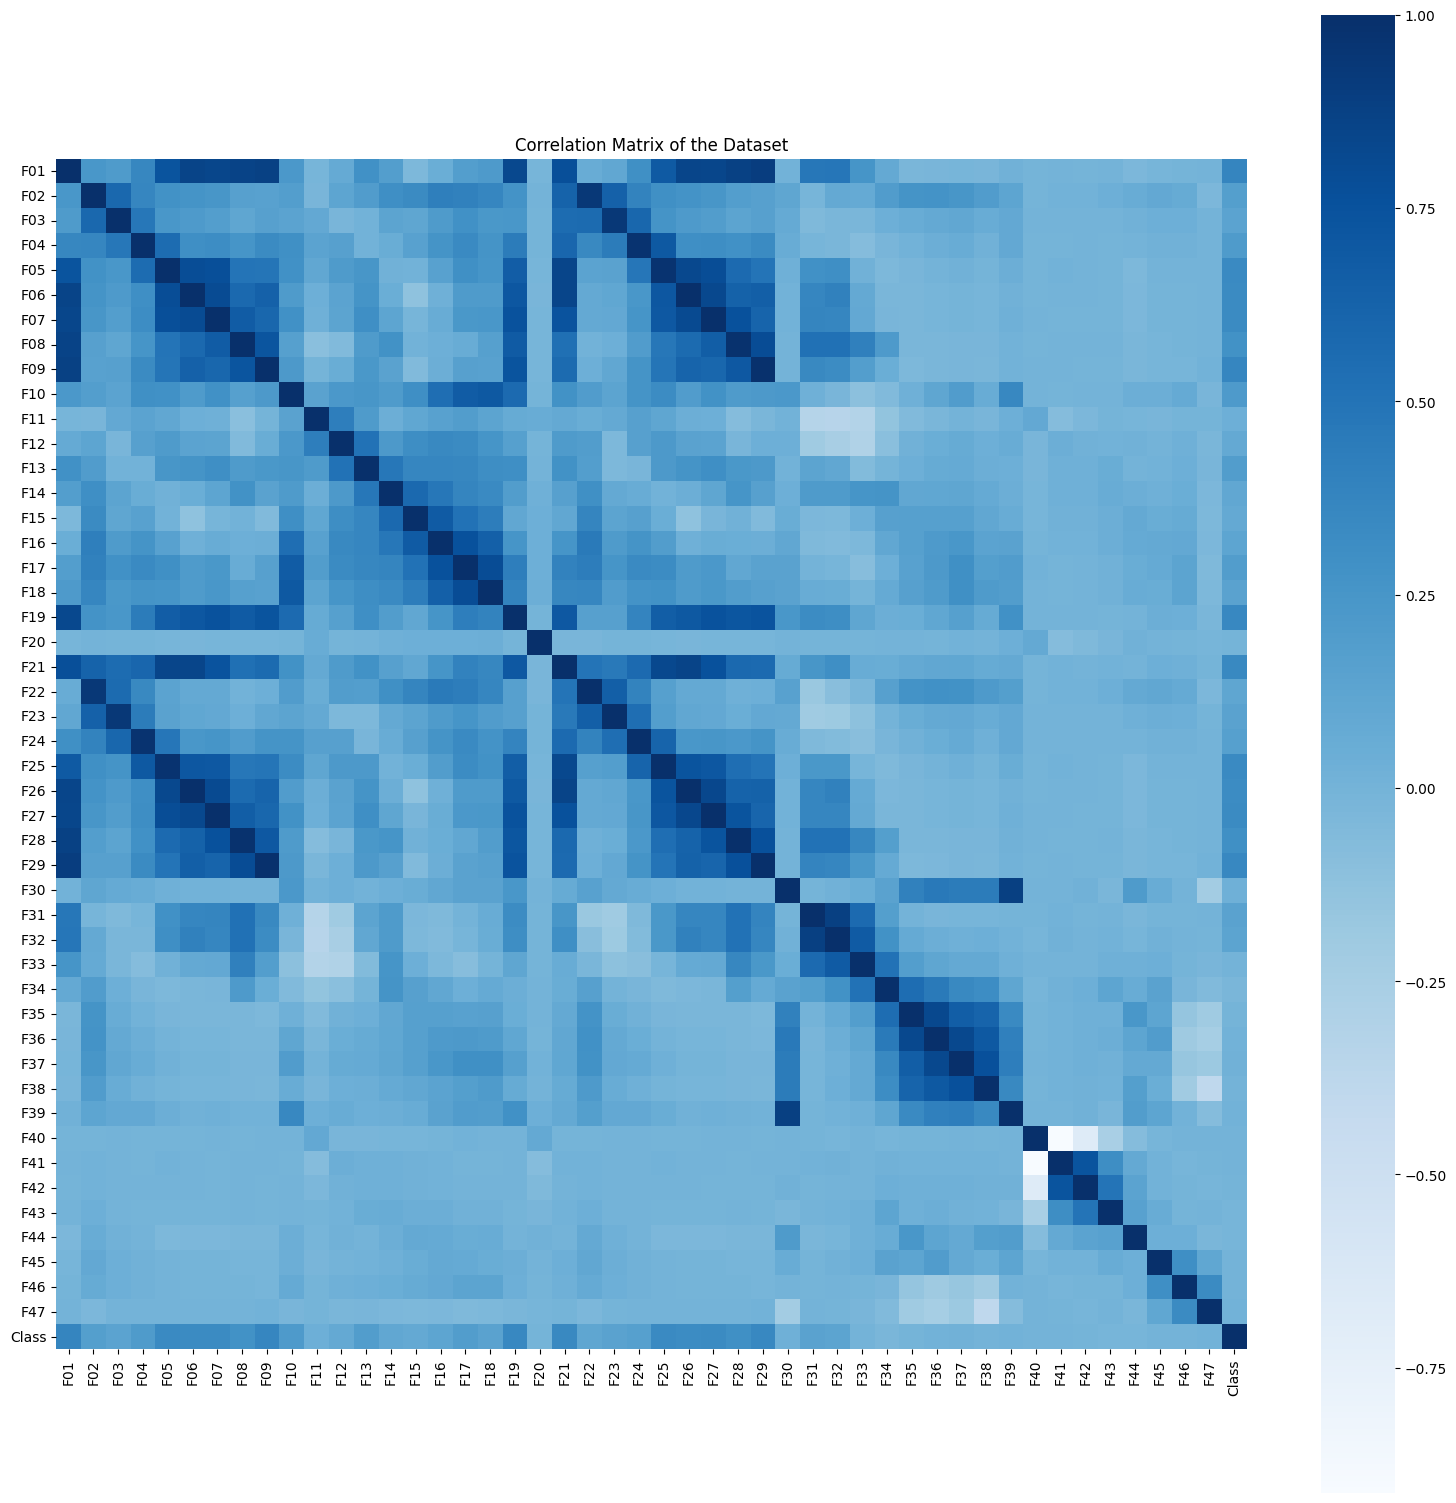

In [483]:
# find the correlation matrix

correlation_matrix = dt_df.corr()

n_features = dt_df.shape[1]
fig_width = max(10, n_features * 0.4)
fig_height = max(8, n_features * 0.4)

plt.figure(figsize=(fig_width, fig_height))
sns.heatmap(correlation_matrix, cbar=True, square=True, fmt='.2f', annot=False, cmap='Blues')
plt.title('Correlation Matrix of the Dataset')
plt.show()

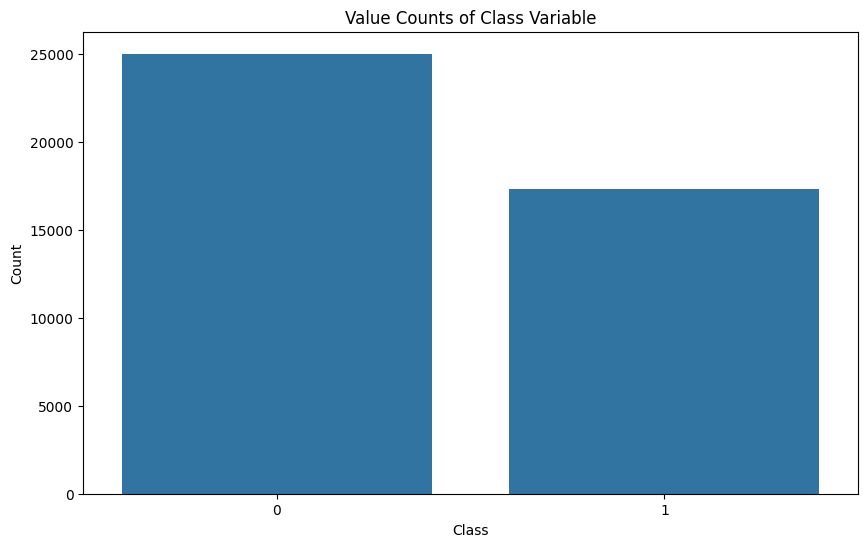

In [484]:
# visualize the value count it not needed but i do.
plt.figure(figsize=(10, 6))
sns.countplot(data=dt_df, x='Class')
plt.title('Value Counts of Class Variable')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Correlation of features with the 'Class' variable:
Class    1.000000
F01      0.378701
F09      0.367824
F29      0.355182
F19      0.351691
F21      0.343452
F05      0.340659
F25      0.337555
F27      0.329485
F07      0.329396
F06      0.328357
F26      0.326734
F28      0.296943
F08      0.276642
F10      0.210862
F04      0.203309
F17      0.189812
F13      0.187870
F02      0.172052
F24      0.164226
F18      0.147966
F31      0.147890
F23      0.145597
F03      0.140719
F32      0.131256
F16      0.121791
F22      0.112751
F14      0.096312
F15      0.085773
F12      0.081574
F11      0.034074
F30      0.021678
F37      0.021008
F36      0.011449
F39      0.009404
F47      0.007042
F46      0.006401
F45      0.004082
F33      0.003740
F40      0.003344
F38      0.003113
F41      0.000301
F20     -0.004974
F42     -0.007020
F35     -0.008160
F43     -0.009309
F44     -0.015504
F34     -0.028146
Name: Class, dtype: float64


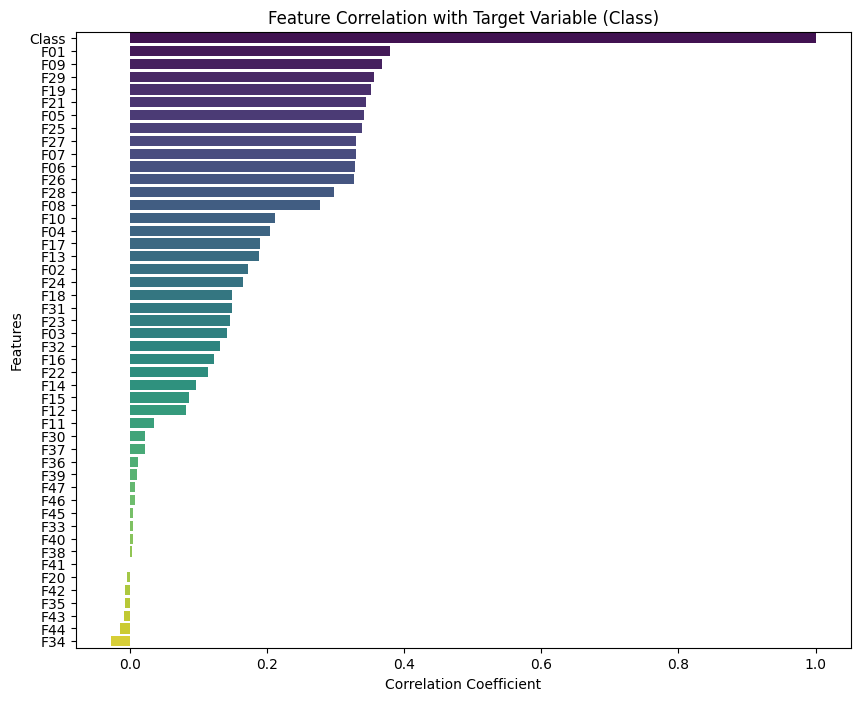

In [485]:
# beacuse we can't understand the with corr matrix
# Get correlations with the target variable 'Class'
correlation_with_target = correlation_matrix['Class'].sort_values(ascending=False)

print("Correlation of features with the 'Class' variable:")
print(correlation_with_target)

plt.figure(figsize=(10, 8))
sns.barplot(x=correlation_with_target.values, y=correlation_with_target.index, hue=correlation_with_target.index, palette='viridis', legend=False)
plt.title('Feature Correlation with Target Variable (Class)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

In [486]:
# standerzied the the data
X = dt_df.drop('Class', axis=1)
y = dt_df['Class']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

dt_df_scaled = pd.DataFrame(X_scaled, columns=X.columns)





print("Head of the standardized DataFrame:")
print(dt_df_scaled.head())

Head of the standardized DataFrame:
        F01       F02       F03       F04       F05       F06       F07  \
0 -0.528372 -0.496954 -0.450651 -0.462243 -0.437414 -0.399225 -0.411977   
1 -0.282405 -0.526508 -0.539497 -0.431819 -0.426146 -0.380342 -0.106802   
2  0.029086 -0.301238 -0.108981 -0.277121 -0.220588 -0.111053 -0.258575   
3 -0.311257  2.541993 -0.079755 -0.302923 -0.431783 -0.389328 -0.410736   
4 -0.464084 -0.110524 -0.238158 -0.098017 -0.329576 -0.372712 -0.402415   

        F08       F09       F10  ...       F38       F39       F40       F41  \
0 -0.394485 -0.515387 -0.318492  ... -0.039895  0.023017 -0.022013 -0.001133   
1  0.172673 -0.534164 -0.779699  ... -0.039156 -0.231108 -0.718120  0.499563   
2  0.124670  0.289814  0.579278  ... -0.036483 -0.018953  1.205482 -0.169820   
3 -0.270874 -0.159888 -0.466313  ... -0.041911  0.230077  0.337631 -1.161322   
4 -0.493257 -0.351547  3.389819  ... -0.012666  0.247710  0.005017 -0.059009   

        F42       F43       F44 

In [487]:
dt_df_scaled.head()

,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47
0,-0.528372,-0.496954,-0.450651,-0.462243,-0.437414,-0.399225,-0.411977,-0.394485,-0.515387,-0.318492,...,-0.039895,0.023017,-0.022013,-0.001133,0.037823,0.006643,0.005983,0.044597,-0.012684,0.033827
1,-0.282405,-0.526508,-0.539497,-0.431819,-0.426146,-0.380342,-0.106802,0.172673,-0.534164,-0.779699,...,-0.039156,-0.231108,-0.718120,0.499563,0.203265,0.041250,-0.123179,-0.016995,0.016355,0.029238
2,0.029086,-0.301238,-0.108981,-0.277121,-0.220588,-0.111053,-0.258575,0.124670,0.289814,0.579278,...,-0.036483,-0.018953,1.205482,-0.169820,-0.177000,-0.045264,0.075632,-0.032169,-0.006999,0.037509
3,-0.311257,2.541993,-0.079755,-0.302923,-0.431783,-0.389328,-0.410736,-0.270874,-0.159888,-0.466313,...,-0.041911,0.230077,0.337631,-1.161322,0.794526,3.060856,3.626974,0.373672,-0.021161,0.030011
4,-0.464084,-0.110524,-0.238158,-0.098017,-0.329576,-0.372712,-0.402415,-0.493257,-0.351547,3.389819,...,-0.012666,0.247710,0.005017,-0.059009,0.004889,-0.602912,0.178025,-0.012924,0.120629,-0.031352


In [506]:
x = dt_df_scaled
y = dt_df['Class']



In [507]:
y.isnull().sum()

np.int64(0)

In [508]:
x_train , x_test , y_train,y_test = train_test_split(x,y,test_size=0.2 , random_state=2)

In [509]:
model= KNeighborsClassifier(p=2)

In [510]:
model.fit(x_train,y_train)

KNeighborsClassifier()

In [511]:
y_pred = model.predict(x_test)
acc = accuracy_score(y_test , y_pred)
print("prediction accuracy of model is ",acc*100)

prediction accuracy of model is  94.94089834515367


In [512]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score of the model is: {f1*100:.2f}%")

F1 Score of the model is: 93.66%


prediction on test data

In [513]:
load = pd.read_csv('/content/drive/MyDrive/ML Challenge Dataset/TEST.csv')

In [514]:
load.head()

,ID,F01,F02,F03,F04,F05,F06,F07,F08,F09,...,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47
0,1,0.277497,0.011515,0.009359,0.011706,0.015613,0.063679,0.021114,0.152000,0.220904,...,2.974426,0.009399,0.015668,0.001999,-0.000937,0.010605,-0.001117,0.043216,-0.000077,-0.040124
1,2,0.158754,0.013861,0.020935,0.002451,0.005939,0.006830,0.006934,0.117209,0.103432,...,2.619811,0.029324,-0.003211,0.037691,-0.083697,0.006595,0.044507,0.007523,-0.000283,-0.007837
2,3,0.504418,0.009106,0.007395,0.009073,0.029486,0.086782,0.122499,0.179376,0.445695,...,4.411972,-0.171520,-0.866895,-0.070657,0.034070,-0.000493,-0.011417,-0.004844,-0.034235,-0.001832
3,4,0.556345,0.005370,0.005670,0.005167,0.013731,0.014570,0.014776,0.522296,0.189882,...,2.709162,0.044236,19.880789,-2.144453,-1.792552,-0.034137,-0.051971,-0.085069,-0.000110,0.045889
4,5,0.128356,0.010014,0.016144,0.003891,0.004472,0.005297,0.007538,0.075874,0.101176,...,2.872020,-0.056908,0.006535,0.070059,-0.007989,0.004089,-0.000206,-0.011331,0.000441,-0.025263


In [496]:
load.isnull().sum()

,0
ID,0
F01,0
F02,0
F03,0
F04,0
F05,0
F06,0
F07,0
F08,0
F09,0


In [515]:
id = load['ID']
load= load.drop('ID', axis=1)



In [516]:
print(id)

0            1
1            2
2            3
3            4
4            5
         ...  
10939    10940
10940    10941
10941    10942
10942    10943
10943    10944
Name: ID, Length: 10944, dtype: int64


In [517]:
load.head()

,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47
0,0.277497,0.011515,0.009359,0.011706,0.015613,0.063679,0.021114,0.152000,0.220904,3.728738,...,2.974426,0.009399,0.015668,0.001999,-0.000937,0.010605,-0.001117,0.043216,-0.000077,-0.040124
1,0.158754,0.013861,0.020935,0.002451,0.005939,0.006830,0.006934,0.117209,0.103432,2.937431,...,2.619811,0.029324,-0.003211,0.037691,-0.083697,0.006595,0.044507,0.007523,-0.000283,-0.007837
2,0.504418,0.009106,0.007395,0.009073,0.029486,0.086782,0.122499,0.179376,0.445695,4.392277,...,4.411972,-0.171520,-0.866895,-0.070657,0.034070,-0.000493,-0.011417,-0.004844,-0.034235,-0.001832
3,0.556345,0.005370,0.005670,0.005167,0.013731,0.014570,0.014776,0.522296,0.189882,2.684893,...,2.709162,0.044236,19.880789,-2.144453,-1.792552,-0.034137,-0.051971,-0.085069,-0.000110,0.045889
4,0.128356,0.010014,0.016144,0.003891,0.004472,0.005297,0.007538,0.075874,0.101176,3.240038,...,2.872020,-0.056908,0.006535,0.070059,-0.007989,0.004089,-0.000206,-0.011331,0.000441,-0.025263


In [518]:
st = scaler.fit_transform(load)
st_df = pd.DataFrame(st,columns=load.columns)


In [501]:
st_df.head()

,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47
0,-0.392847,-0.130846,-0.275203,-0.296295,-0.389054,-0.240247,-0.395167,-0.288600,-0.317515,-0.017225,...,-0.038745,-0.020550,0.009733,-0.006281,-0.009611,0.022222,-0.015705,0.147240,-0.025074,-0.087603
1,-0.555300,-0.008355,0.262166,-0.488154,-0.442847,-0.388273,-0.439465,-0.388002,-0.582848,-0.712107,...,-0.040619,0.022967,0.007522,0.015570,-0.084980,0.010853,0.190644,0.019233,-0.025775,-0.013006
2,-0.082394,-0.256626,-0.366373,-0.350878,-0.311911,-0.180091,-0.078445,-0.210383,0.190221,0.565459,...,-0.031150,-0.415685,-0.093641,-0.050762,0.022270,-0.009241,-0.062290,-0.025120,-0.141260,0.000869
3,-0.011352,-0.451693,-0.446449,-0.431850,-0.399519,-0.368119,-0.414967,0.769378,-0.387584,-0.933872,...,-0.040146,0.055536,2.336515,-1.320379,-1.641229,-0.104622,-0.245708,-0.312833,-0.025186,0.111125
4,-0.596888,-0.209217,0.039763,-0.458302,-0.451005,-0.392265,-0.437578,-0.506100,-0.587944,-0.446374,...,-0.039286,-0.165367,0.008663,0.035387,-0.016033,0.003749,-0.011585,-0.048384,-0.023312,-0.053267


In [519]:
test_pred = model.predict(st_df)

In [521]:
print(test_pred)

[1 0 1 ... 1 1 1]


In [520]:
FINAL_df = pd.DataFrame(id)
FINAL_df['Class'] = test_pred



In [522]:
FINAL_df.head()

,ID,Class
0,1,1
1,2,0
2,3,1
3,4,0
4,5,0


In [523]:
FINAL_df.value_counts('Class')

,count
Class,
0,6766
1,4178
